In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import math
from collections import defaultdict, Counter
from scipy.spatial import KDTree
from ast import literal_eval

# Для работы со структурами
from pymatgen.core import Structure, Lattice
from pymatgen.core.structure import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# Установка device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# %% [markdown]
# ## 2. Загрузка данных и разведочный анализ (EDA)
#
# ### Описание датасета:
# - **Объект**: кристаллическая структура материала
# - **Признаки**: кристаллическая структура (pymatgen), химический состав
# - **Целевая переменная**: formation_energy_per_atom (эВ/атом)
#
# ### Размер данных:
# - MP18: 69,239 структур
# - MP21: 7,800 структур
# - Train (MP18 → MP21): 2,261 структура
# - Test (новые в MP21): 5,539 структур
#
# ### Предобработка:
# - Удалены классы элементов с 1 образцом
# - Стратифицированное разделение MP18 на pre-train (80%) и fine-tune (20%)
# - Pre-train разделен на train (80%) и validation (20%)

# %%
# Загрузка данных
df_all = pd.read_csv("MP_alloys_2021.11.10_273feat.csv")
df_mp18_all = pd.read_csv("megnet_updated_id_MP21.csv")

print(f"Число структур в MP18: {len(df_mp18_all)}")
print(f"Число структур в MP21: {len(df_all)}")

# Получаем все material_id из df_all
all_aoi_ids = set(df_all['material_id'].tolist())
print(f"Всего материалов ID в MP21: {len(all_aoi_ids)}")

# Смотрим, какие из них есть в MP18
df_map_aoi = df_mp18_all[df_mp18_all['id_MP21'].isin(all_aoi_ids)].copy()
print(f"Из них есть: {len(df_map_aoi)}")
print(f"Это те структуры, которые были в MP18")

# Получаем список id для train
mp18_aoi_ids = set(df_map_aoi['id_MP21'].tolist())

# Разделяем на train (MP18) и test (MP21 new)
train_df = df_all[df_all['material_id'].isin(mp18_aoi_ids)].copy()
test_df = df_all[~df_all['material_id'].isin(mp18_aoi_ids)].copy()

print(f"\n--- ИТОГОВОЕ РАЗДЕЛЕНИЕ ---")
print(f"Train (были в MP18): {len(train_df)}")
print(f"Test (новые в MP21): {len(test_df)}")
print(f"Всего: {len(train_df) + len(test_df)} (должно быть {len(df_all)})")

# Считаем количество образцов в каждом классе элементов
elem_counts = train_df['elements'].value_counts()

# Оставляем только те классы, где больше 1 образца
valid_elements = elem_counts[elem_counts > 1].index
train_df_filtered = train_df[train_df['elements'].isin(valid_elements)]

print(f"\nПосле фильтрации классов с 1 образцом: {len(train_df_filtered)}")
print(f"Удалено классов с 1 образцом: {len(elem_counts[elem_counts == 1])}")

# Стратифицированное разделение на pre_train и fine_tune
pre_train, fine_tune = train_test_split(
    train_df_filtered,
    test_size=0.3,
    stratify=train_df_filtered['elements'],
    random_state=42,
    shuffle=True
)

print(f"\n--- РАЗДЕЛЕНИЕ MP18 НА PRE-TRAIN И FINE-TUNE ---")
print(f"Pre-train (для предобучения GNN): {len(pre_train)}")
print(f"Fine-tune (для обучения SVR): {len(fine_tune)}")
print(f"Test (MP21 new): {len(test_df)}")

# Разделяем pre_train на train и validation
pre_train_df, val_df = train_test_split(
    pre_train,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(f"\nPre-train train: {len(pre_train_df)}")
print(f"Pre-train validation: {len(val_df)}")

Число структур в MP18: 69239
Число структур в MP21: 7800
Всего материалов ID в MP21: 7800
Из них есть: 2261
Это те структуры, которые были в MP18

--- ИТОГОВОЕ РАЗДЕЛЕНИЕ ---
Train (были в MP18): 2261
Test (новые в MP21): 5539
Всего: 7800 (должно быть 7800)

После фильтрации классов с 1 образцом: 1685
Удалено классов с 1 образцом: 576

--- РАЗДЕЛЕНИЕ MP18 НА PRE-TRAIN И FINE-TUNE ---
Pre-train (для предобучения GNN): 1179
Fine-tune (для обучения SVR): 506
Test (MP21 new): 5539

Pre-train train: 943
Pre-train validation: 236


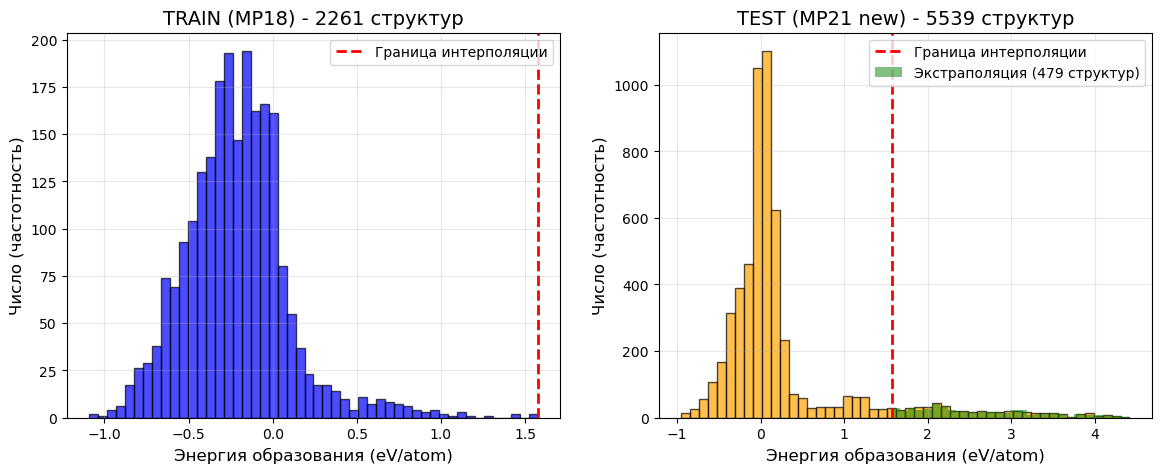

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].hist(train_df['formation_energy_per_atom'], bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=1.575, color='red', linestyle='--', linewidth=2, label='Граница интерполяции')
axes[0].set_xlabel('Энергия образования (eV/atom)', fontsize=12)
axes[0].set_ylabel('Число (частотность)', fontsize=12)
axes[0].set_title(f'TRAIN (MP18) - {len(train_df)} структур', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].hist(test_df['formation_energy_per_atom'], bins=50, color='orange', alpha=0.7, edgecolor='black')
axes[1].axvline(x=1.575, color='red', linestyle='--', linewidth=2, label='Граница интерполяции')
# Подсветка экстраполяционной части
test_extrap = test_df[test_df['formation_energy_per_atom'] > 1.575]
axes[1].hist(test_extrap['formation_energy_per_atom'], bins=30, color='g', alpha=0.5, label=f'Экстраполяция ({len(test_extrap)} структур)')
axes[1].set_xlabel('Энергия образования (eV/atom)', fontsize=12)
axes[1].set_ylabel('Число (частотность)', fontsize=12)
axes[1].set_title(f'TEST (MP21 new) - {len(test_df)} структур', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.show()

**Выводы:**

Видно что на графике Train много примеров соединений лежащих в окрестности нуля. Также следует заметить, что чисто физически более устойчивые соединения с отрицательной энергией образования, что мы явно видим в нашем распределении. Также следует отметить малое число данных в области "Энергии образования" > 0.5 эВ/атом. Рассмотрим график Test: Большая часть соединений датасета MP21 содержит соединения с "Энергии образования", лежащими в окрестности 0.0. Однако на графике заметен существенный "хвост" значения "Энергии образования", которого лежат в диаппазоне (1.5 - 4.0). В результате того, что на Train не было данных с подобными значениями, то модель сквозного обучения ("чисто" CGCNN) плохо будет предсказывать данные. Решением этой проблемы будет добавление блока регрессора (в нашем случаии SVR).

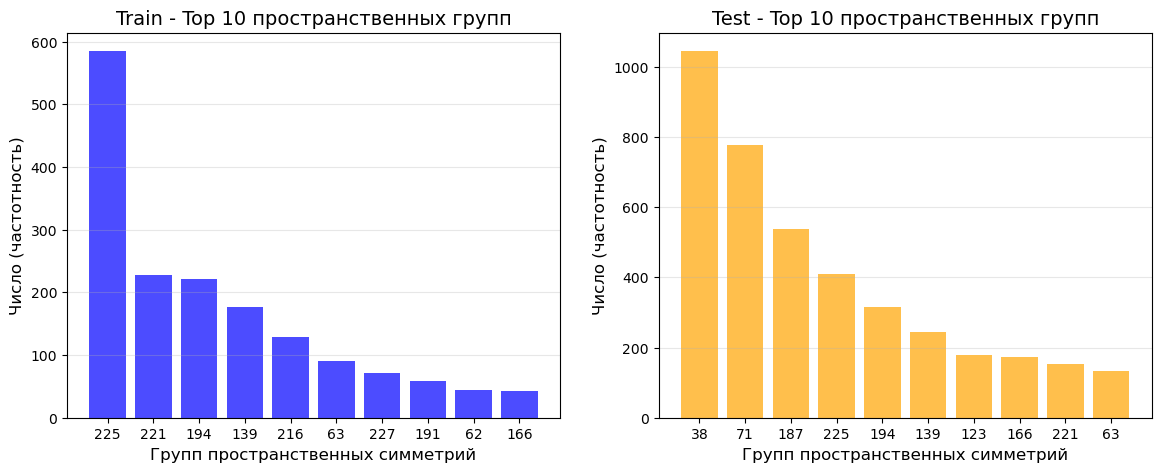

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
train_sg_counts = train_df['space_group_number'].value_counts().head(10)
axes[0].bar(range(len(train_sg_counts)), train_sg_counts.values, color='blue', alpha=0.7)
axes[0].set_xticks(range(len(train_sg_counts)))
axes[0].set_xticklabels(train_sg_counts.index)
axes[0].set_xlabel('Групп пространственных симметрий', fontsize=12)
axes[0].set_ylabel('Число (частотность)', fontsize=12)
axes[0].set_title(f'Train - Top 10 пространственных групп', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Test
test_sg_counts = test_df['space_group_number'].value_counts().head(10)
axes[1].bar(range(len(test_sg_counts)), test_sg_counts.values, color='orange', alpha=0.7)
axes[1].set_xticks(range(len(test_sg_counts)))
axes[1].set_xticklabels(test_sg_counts.index)
axes[1].set_xlabel('Групп пространственных симметрий', fontsize=12)
axes[1].set_ylabel('Число (частотность)', fontsize=12)
axes[1].set_title(f'Test - Top 10 пространственных групп', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.show()

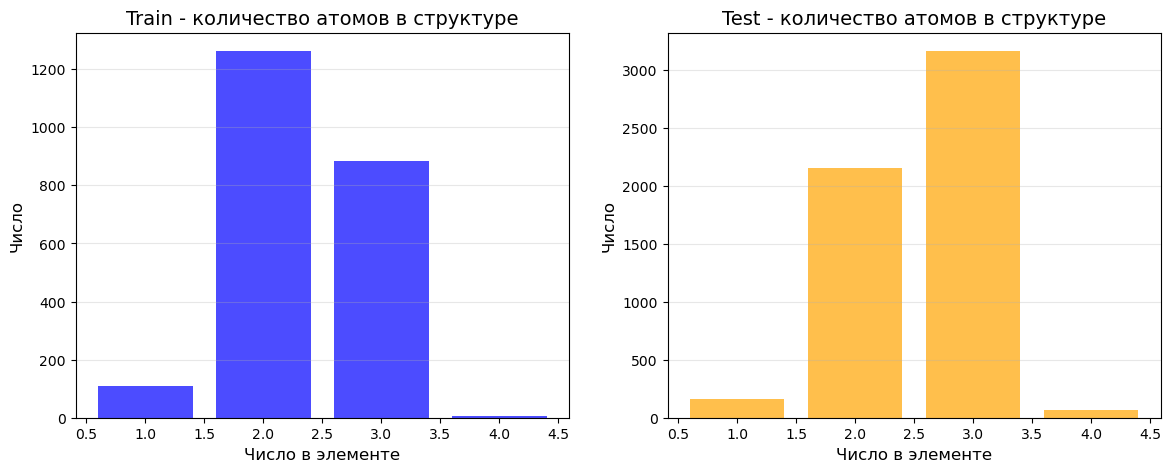

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
train_nelements = train_df['nelements'].value_counts().sort_index()
axes[0].bar(train_nelements.index, train_nelements.values, color='blue', alpha=0.7)
axes[0].set_xlabel('Число в элементе', fontsize=12)
axes[0].set_ylabel('Число', fontsize=12)
axes[0].set_title(f'Train - количество атомов в структуре', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Test
test_nelements = test_df['nelements'].value_counts().sort_index()
axes[1].bar(test_nelements.index, test_nelements.values, color='orange', alpha=0.7)
axes[1].set_xlabel('Число в элементе', fontsize=12)
axes[1].set_ylabel('Число', fontsize=12)
axes[1].set_title(f'Test - количество атомов в структуре', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')
plt.show()

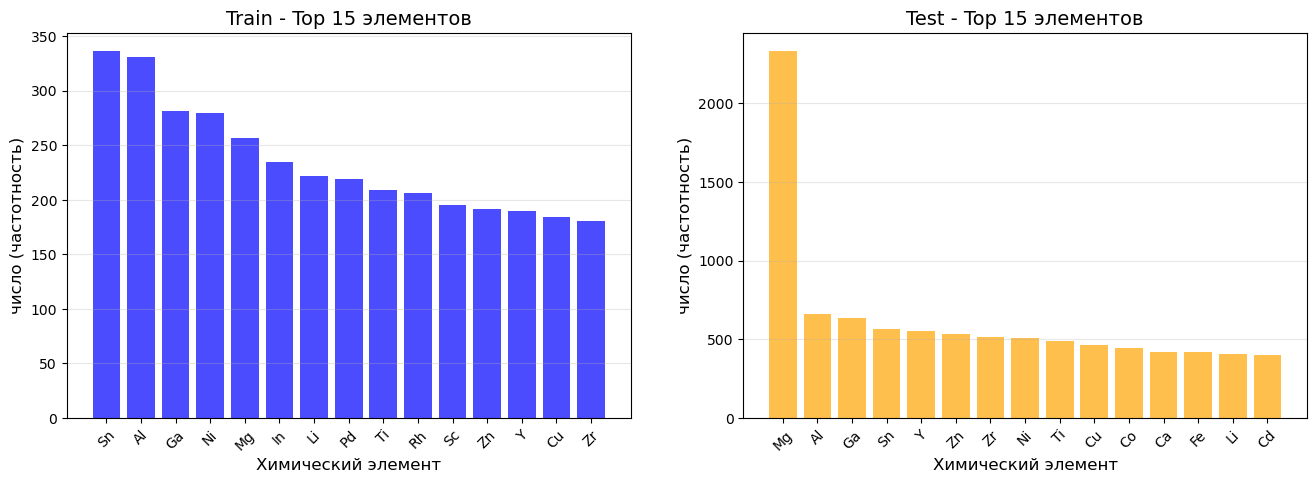

In [ ]:
# Функция для подсчета элементов
def count_elements(df):
    all_elements = []
    for elem_list in df['elements']:
        try:
            elements = literal_eval(elem_list)
            all_elements.extend(elements)
        except:
            pass
    return Counter(all_elements)

# Подсчет
train_elements = count_elements(train_df)
test_elements = count_elements(test_df)

# Топ-15
top_train = dict(train_elements.most_common(15))
top_test = dict(test_elements.most_common(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Train
axes[0].bar(top_train.keys(), top_train.values(), color='blue', alpha=0.7)
axes[0].set_xlabel('Химический элемент', fontsize=12)
axes[0].set_ylabel('число (частотность)', fontsize=12)
axes[0].set_title('Train - Top 15 элементов', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Test
axes[1].bar(top_test.keys(), top_test.values(), color='orange', alpha=0.7)
axes[1].set_xlabel('Химический элемент', fontsize=12)
axes[1].set_ylabel('число (частотность)', fontsize=12)
axes[1].set_title('Test - Top 15 элементов', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.show()

In [ ]:
# %% [markdown]
# ## 3. Вспомогательные функции для работы со структурами

# %%
def pymatgen_to_ase_structure(pmg_struct):
    """Конвертирует pymatgen Structure в ASE Atoms."""
    try:
        from ase import Atoms
        from pymatgen.io.ase import AseAtomsAdaptor
        return AseAtomsAdaptor.get_atoms(pmg_struct)
    except:
        return None

def get_atomic_numbers(structure):
    """Получает атомные номера всех атомов в структуре."""
    return [site.specie.number for site in structure.sites]

def get_positions(structure):
    """Получает координаты всех атомов в структуре."""
    return [[site.x, site.y, site.z] for site in structure.sites]

def parse_structure(structure_str):
    """Парсит строку со структурой в pymatgen Structure."""
    try:
        structure_dict = eval(structure_str)
        return Structure.from_dict(structure_dict)
    except:
        try:
            import ast
            structure_dict = ast.literal_eval(structure_str)
            return Structure.from_dict(structure_dict)
        except:
            print(f"Не удалось распарсить структуру: {structure_str[:100]}...")
            return None

In [ ]:
# %% [markdown]
# ## 4. Улучшенная CGCNN
#
# Улучшения:
# - Cosine envelope для плавного затухания связей
# - SiLU (Swish) активация вместо ReLU
# - LayerNorm для стабилизации
# - Обработка структур без соседей

# %%
class CosineEnvelope(nn.Module):
    """Плавная обрезающая функция для расстояний"""
    def __init__(self, cutoff=8.0, exponent=5):
        super().__init__()
        self.cutoff = cutoff
        self.p = exponent

    def forward(self, distances):
        distances = distances.clamp(max=self.cutoff)
        x = distances / self.cutoff
        envelope = 1 - (self.p+1)*(self.p+2)/2 * x**self.p + \
                   self.p*(self.p+2) * x**(self.p+1) - \
                   self.p*(self.p+1)/2 * x**(self.p+2)
        return envelope


class ImprovedCGCNNConv(nn.Module):
    """Улучшенный слой свертки CGCNN"""
    def __init__(self, in_fea, out_fea, cutoff=8.0):
        super().__init__()
        self.in_fea = in_fea
        self.out_fea = out_fea
        self.cutoff = cutoff
        self.linear = nn.Linear(in_fea + 1, out_fea)
        self.envelope = CosineEnvelope(cutoff)
        self.layernorm = nn.LayerNorm(out_fea)

    def forward(self, atom_fea, nbr_fea, nbr_fea_idx):
        nbr_atom_fea = atom_fea[nbr_fea_idx[1]]

        if nbr_fea.dim() == 1:
            nbr_fea = nbr_fea.unsqueeze(1)

        # Применяем envelope к расстояниям
        envelope = self.envelope(nbr_fea.squeeze()).unsqueeze(1)
        nbr_fea = nbr_fea * envelope

        nbr_combined = torch.cat([nbr_atom_fea, nbr_fea], dim=1)
        nbr_updated = self.linear(nbr_combined)

        central_indices = nbr_fea_idx[0]
        new_atom_fea = atom_fea.clone()
        new_atom_fea = new_atom_fea.index_add(0, central_indices, nbr_updated)
        new_atom_fea = self.layernorm(new_atom_fea)

        return new_atom_fea


class ImprovedCGCNN(nn.Module):
    """Улучшенная CGCNN с envelope и SiLU"""
    def __init__(self, atom_fea_len=64, n_conv=3, h_fea_len=128, cutoff=8.0):
        super().__init__()
        self.atom_fea_len = atom_fea_len
        self.n_conv = n_conv
        self.h_fea_len = h_fea_len
        self.cutoff = cutoff

        self.embedding = nn.Embedding(93, atom_fea_len)
        self.convs = nn.ModuleList([
            ImprovedCGCNNConv(atom_fea_len, atom_fea_len, cutoff) for _ in range(n_conv)
        ])

        self.fc1 = nn.Linear(atom_fea_len, h_fea_len)
        self.fc2 = nn.Linear(h_fea_len, h_fea_len)
        self.fc_out = nn.Linear(h_fea_len, 1)
        self.dropout = nn.Dropout(0.1)
        self.activation = nn.SiLU()

    def forward(self, atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx):
        atom_fea = self.embedding(atom_fea)

        for conv in self.convs:
            atom_fea = conv(atom_fea, nbr_fea, nbr_fea_idx)

        crystal_fea = []
        for idx in crystal_atom_idx:
            if len(idx) > 0:
                crystal_fea.append(atom_fea[idx].mean(dim=0))
            else:
                crystal_fea.append(torch.zeros(atom_fea.size(1), device=atom_fea.device))
        crystal_fea = torch.stack(crystal_fea)

        x = self.activation(self.fc1(crystal_fea))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        out = self.fc_out(x)
        return out

    def extract_features(self, atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx):
        """Извлечение признаков для SVR"""
        atom_fea = self.embedding(atom_fea)

        for conv in self.convs:
            atom_fea = conv(atom_fea, nbr_fea, nbr_fea_idx)

        crystal_fea = []
        for idx in crystal_atom_idx:
            if len(idx) > 0:
                crystal_fea.append(atom_fea[idx].mean(dim=0))
            else:
                crystal_fea.append(torch.zeros(atom_fea.size(1), device=atom_fea.device))
        crystal_fea = torch.stack(crystal_fea)

        x = self.activation(self.fc1(crystal_fea))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        return x


class CGCNNDataset(Dataset):
    """Dataset для CGCNN с обработкой ошибок"""
    def __init__(self, df, radius=8.0, max_neighbors=50):
        self.df = df.reset_index(drop=True)
        self.radius = radius
        self.max_neighbors = max_neighbors
        self.valid_indices = []
        self.structures_cache = {}
        self.structures_list = []  # Для последовательного доступа

        print(f"Загрузка CGCNNDataset из {len(df)} структур...")

        for idx in range(len(df)):
            try:
                row = df.iloc[idx]
                structure = None

                if 'structure' in row and row['structure']:
                    try:
                        if isinstance(row['structure'], dict):
                            structure = Structure.from_dict(row['structure'])
                        else:
                            structure_dict = eval(row['structure'])
                            structure = Structure.from_dict(structure_dict)
                    except:
                        pass

                if structure is None and 'structure_as_dict' in row and row['structure_as_dict']:
                    try:
                        if isinstance(row['structure_as_dict'], dict):
                            structure = Structure.from_dict(row['structure_as_dict'])
                        else:
                            structure_dict = eval(row['structure_as_dict'])
                            structure = Structure.from_dict(structure_dict)
                    except:
                        pass

                if structure is not None:
                    self.structures_cache[idx] = structure
                    self.structures_list.append(structure)
                    self.valid_indices.append(idx)

            except Exception as e:
                print(f"  Предупреждение: не удалось загрузить структуру {idx}: {e}")
                continue

        print(f"CGCNNDataset: успешно загружено {len(self.valid_indices)} из {len(df)} структур")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        structure = self.structures_cache[real_idx]
        target = self.df.iloc[real_idx]['formation_energy_per_atom']

        atom_features = []
        positions = []
        for site in structure.sites:
            atom_features.append(site.specie.number)
            positions.append([site.x, site.y, site.z])

        positions = np.array(positions)
        n_atoms = len(atom_features)

        neighbors = []
        distances = []

        # Если атом всего один, добавляем фиктивную связь с самим собой
        if n_atoms == 1:
            neighbors = [[0, 0]]
            distances = [0.0]
        else:
            for i in range(n_atoms):
                pos_i = positions[i]
                nbr_count = 0
                for j in range(n_atoms):
                    if i != j:
                        dist = np.linalg.norm(positions[j] - pos_i)
                        if dist <= self.radius:
                            neighbors.append([i, j])
                            distances.append(dist)
                            nbr_count += 1
                            if nbr_count >= self.max_neighbors:
                                break

        # Если нет соседей (изолированный атом), добавляем фиктивную связь
        if len(neighbors) == 0:
            neighbors = [[0, 0]]
            distances = [0.0]

        atom_fea = torch.tensor(atom_features, dtype=torch.long)
        nbr_fea = torch.tensor(distances, dtype=torch.float)
        nbr_fea_idx = torch.tensor(neighbors, dtype=torch.long).t()
        target = torch.tensor([target], dtype=torch.float)

        return atom_fea, nbr_fea, nbr_fea_idx, target


def collate_cgcnn_batch(batch):
    """Custom collate function для CGCNN"""
    if len(batch) == 0:
        return None

    atom_fea_list = []
    nbr_fea_list = []
    nbr_fea_idx_list = []
    targets = []
    crystal_atom_idx = []

    offset = 0
    for item in batch:
        atom_fea, nbr_fea, nbr_fea_idx, target = item

        n_atoms = len(atom_fea)
        crystal_atom_idx.append(torch.arange(offset, offset + n_atoms, dtype=torch.long))

        nbr_fea_idx_shifted = nbr_fea_idx.clone()
        nbr_fea_idx_shifted[0] += offset
        nbr_fea_idx_shifted[1] += offset

        atom_fea_list.append(atom_fea)
        nbr_fea_list.append(nbr_fea)
        nbr_fea_idx_list.append(nbr_fea_idx_shifted)
        targets.append(target)

        offset += n_atoms

    atom_fea = torch.cat(atom_fea_list)
    nbr_fea = torch.cat(nbr_fea_list)
    nbr_fea_idx = torch.cat(nbr_fea_idx_list, dim=1)
    targets = torch.stack(targets)

    return atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx, targets

In [ ]:
# %% [markdown]
# ## 5. Улучшенная SchNet
#
# Улучшения:
# - Cosine cutoff для плавного затухания
# - ShiftedSoftplus активация
# - Более глубокая сеть фильтров

# %%
class ShiftedSoftplus(nn.Module):
    """Shifted Softplus activation: ln(1 + e^x) - ln(2)"""
    def forward(self, x):
        return F.softplus(x) - math.log(2.0)


class CosineCutoff(nn.Module):
    """Cosine cutoff function для плавного затухания"""
    def __init__(self, cutoff=5.0):
        super().__init__()
        self.cutoff = cutoff

    def forward(self, distances):
        distances = distances.clamp(max=self.cutoff)
        x = distances / self.cutoff
        return 0.5 * (torch.cos(math.pi * x) + 1.0)


class ImprovedSchNetInteraction(nn.Module):
    """Улучшенный interaction block для SchNet"""
    def __init__(self, n_atom_basis, n_filters, cutoff=5.0):
        super().__init__()
        self.n_atom_basis = n_atom_basis
        self.n_filters = n_filters
        self.cutoff = cutoff

        self.cutoff_fn = CosineCutoff(cutoff)

        self.filter_network = nn.Sequential(
            nn.Linear(1, n_filters),
            ShiftedSoftplus(),
            nn.Linear(n_filters, n_filters),
            ShiftedSoftplus(),
            nn.Linear(n_filters, n_atom_basis)
        )

        self.dense = nn.Linear(n_atom_basis, n_atom_basis)
        self.layernorm = nn.LayerNorm(n_atom_basis)

    def forward(self, x, positions):
        n_atoms = len(x)
        distances = torch.cdist(positions, positions)

        # Применяем cutoff
        cutoff_mask = self.cutoff_fn(distances)

        filters = self.filter_network(distances.unsqueeze(-1))
        filters = filters * cutoff_mask.unsqueeze(-1)

        # Агрегация
        aggregated = torch.einsum('ij,ijk->ik', distances, filters)
        x = self.layernorm(x + self.dense(aggregated))
        return x


class ImprovedSchNet(nn.Module):
    """Улучшенная SchNet с cosine cutoff"""
    def __init__(self, n_atom_basis=64, n_filters=64, n_interactions=3, cutoff=5.0):
        super().__init__()
        self.n_atom_basis = n_atom_basis
        self.n_filters = n_filters
        self.n_interactions = n_interactions
        self.cutoff = cutoff

        self.embedding = nn.Embedding(93, n_atom_basis)
        self.interactions = nn.ModuleList([
            ImprovedSchNetInteraction(n_atom_basis, n_filters, cutoff)
            for _ in range(n_interactions)
        ])

        self.fc1 = nn.Linear(n_atom_basis, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, 1)
        self.dropout = nn.Dropout(0.1)
        self.activation = ShiftedSoftplus()

    def forward(self, atom_types, positions):
        x = self.embedding(atom_types)
        for interaction in self.interactions:
            x = interaction(x, positions)
        x = x.mean(dim=0, keepdim=True)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        out = self.fc_out(x)
        return out

    def extract_features(self, atom_types, positions):
        """Извлечение признаков для SVR"""
        x = self.embedding(atom_types)
        for interaction in self.interactions:
            x = interaction(x, positions)
        x = x.mean(dim=0, keepdim=True)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        return x


class SchNetDataset(Dataset):
    """Dataset для SchNet"""
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.valid_indices = []
        self.structures_cache = {}

        print(f"Загрузка SchNetDataset из {len(df)} структур...")

        for idx in range(len(df)):
            try:
                row = df.iloc[idx]
                structure = None

                if 'structure' in row and row['structure']:
                    try:
                        structure_dict = eval(row['structure'])
                        structure = Structure.from_dict(structure_dict)
                    except:
                        pass

                if structure is None and 'structure_as_dict' in row and row['structure_as_dict']:
                    try:
                        structure_dict = eval(row['structure_as_dict'])
                        structure = Structure.from_dict(structure_dict)
                    except:
                        pass

                if structure is not None:
                    self.structures_cache[idx] = structure
                    self.valid_indices.append(idx)

            except Exception as e:
                continue

        print(f"SchNetDataset: успешно загружено {len(self.valid_indices)} из {len(df)} структур")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        structure = self.structures_cache[real_idx]
        target = self.df.iloc[real_idx]['formation_energy_per_atom']

        atom_types = torch.tensor([site.specie.number for site in structure.sites], dtype=torch.long)
        positions = torch.tensor([[site.x, site.y, site.z] for site in structure.sites], dtype=torch.float)
        target = torch.tensor([target], dtype=torch.float)

        return atom_types, positions, target


def collate_schnet_batch(batch):
    """Custom collate function для SchNet"""
    if len(batch) == 0:
        return None

    atom_types_list = [item[0] for item in batch]
    positions_list = [item[1] for item in batch]
    targets = torch.stack([item[2] for item in batch])

    atom_types = torch.cat(atom_types_list)
    positions = torch.cat(positions_list)

    return atom_types, positions, targets

In [ ]:
# %% [markdown]
# ## 6. Полноценная DimeNet++ с учетом углов

# %%
class GaussianRBF(nn.Module):
    """Radial Basis Functions для расстояний"""
    def __init__(self, num_radial=32, cutoff=5.0, envelope_exponent=5):
        super().__init__()
        self.num_radial = num_radial
        self.cutoff = cutoff
        self.envelope_exponent = envelope_exponent

        centers = torch.linspace(0, cutoff, num_radial)
        self.centers = nn.Parameter(centers, requires_grad=False)
        self.gamma = (num_radial / cutoff) ** 2

    def envelope(self, distances):
        distances = distances.clamp(max=self.cutoff)
        p = self.envelope_exponent
        x = distances / self.cutoff
        envelope = 1 - (p+1)*(p+2)/2 * x**p + p*(p+2) * x**(p+1) - p*(p+1)/2 * x**(p+2)
        return envelope

    def forward(self, distances):
        distances = distances.unsqueeze(1)
        rbf = torch.exp(-self.gamma * (distances - self.centers) ** 2)
        envelope = self.envelope(distances.squeeze(-1)).unsqueeze(1)
        return rbf * envelope


class DimeNetInteraction(nn.Module):
    """Directional Message Passing Layer для DimeNet++ (упрощённая версия)"""
    def __init__(self, emb_size=128, num_radial=32, dropout=0.1):
        super().__init__()
        self.emb_size = emb_size

        # message MLP: вход = [атомные признаки + радиальные признаки]
        self.message_mlp = nn.Sequential(
            nn.Linear(emb_size + num_radial, emb_size * 2),
            nn.SiLU(),
            nn.Linear(emb_size * 2, emb_size),
            nn.Dropout(dropout)
        )

        self.update_mlp = nn.Sequential(
            nn.LayerNorm(emb_size),
            nn.Linear(emb_size, emb_size),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_size, emb_size)
        )

    def forward(self, x, edge_index, radial):
        """
        Args:
            x: [num_atoms, emb_size]
            edge_index: [2, num_edges]
            radial: [num_edges, num_radial]
        """
        src, dst = edge_index
        src_features = x[src]  # [E, H]

        # Комбинируем атомные признаки с радиальными
        combined = torch.cat([src_features, radial], dim=1)
        messages = self.message_mlp(combined)  # [E, H]

        # Агрегация
        new_x = x.clone()
        for i in range(len(x)):
            mask = (dst == i)
            if mask.any():
                new_x[i] = new_x[i] + messages[mask].sum(dim=0)

        new_x = self.update_mlp(new_x)
        return new_x


class CompleteDimeNetPlusPlus(nn.Module):
    """
    DimeNet++ с учётом углов через отдельную обработку
    """
    def __init__(self, num_atoms=93, emb_size=128, num_blocks=4,
                 num_radial=32, cutoff=5.0):
        super().__init__()
        self.emb_size = emb_size
        self.num_blocks = num_blocks
        self.cutoff = cutoff
        self.num_radial = num_radial

        self.atom_embedding = nn.Embedding(num_atoms, emb_size)
        self.rbf = GaussianRBF(num_radial, cutoff)

        # Угловая обработка
        self.angle_mlp = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, emb_size)
        )

        self.interactions = nn.ModuleList([
            DimeNetInteraction(emb_size, num_radial)
            for _ in range(num_blocks)
        ])

        self.out_mlp = nn.Sequential(
            nn.Linear(emb_size, emb_size),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(emb_size, emb_size // 2),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(emb_size // 2, 1)
        )

    def compute_edges_and_angles(self, positions):
        """
        Вычисляет рёбра и усреднённые угловые признаки для каждого атома
        """
        n_atoms = len(positions)

        # Находим всех соседей
        edge_index = []
        edge_distances = []

        for i in range(n_atoms):
            for j in range(n_atoms):
                if i != j:
                    dist = torch.norm(positions[i] - positions[j])
                    if dist <= self.cutoff:
                        edge_index.append([i, j])
                        edge_distances.append(dist)

        if len(edge_index) == 0:
            edge_index = [[0, 0]]
            edge_distances = [0.0]

        edge_index = torch.tensor(edge_index, dtype=torch.long).t()
        edge_distances = torch.tensor(edge_distances, dtype=torch.float)

        # Вычисляем угловые признаки для каждого атома (усреднение по всем углам)
        angle_features = torch.zeros(n_atoms, self.emb_size, device=positions.device)
        angle_counts = torch.zeros(n_atoms, device=positions.device)

        for i in range(n_atoms):
            # Находим всех соседей атома i
            neighbors = []
            for e_idx in range(edge_index.size(1)):
                if edge_index[1][e_idx] == i:
                    neighbors.append(edge_index[0][e_idx].item())

            if len(neighbors) < 2:
                continue

            # Для каждой пары соседей вычисляем угол
            for idx1 in range(len(neighbors)):
                for idx2 in range(idx1 + 1, len(neighbors)):
                    k = neighbors[idx1]
                    j = neighbors[idx2]

                    vec_ik = positions[k] - positions[i]
                    vec_ij = positions[j] - positions[i]

                    cos_angle = torch.dot(vec_ik, vec_ij) / (torch.norm(vec_ik) * torch.norm(vec_ij) + 1e-8)
                    angle = torch.acos(cos_angle.clamp(-0.999999, 0.999999))

                    # Добавляем угловой признак
                    angle_features[i] += self.angle_mlp(angle.unsqueeze(0).unsqueeze(0)).squeeze()
                    angle_counts[i] += 1

        # Усредняем
        for i in range(n_atoms):
            if angle_counts[i] > 0:
                angle_features[i] = angle_features[i] / angle_counts[i]

        return edge_index, edge_distances, angle_features

    def forward(self, atom_types, positions):
        x = self.atom_embedding(atom_types)  # [N, H]

        edge_index, edge_distances, angle_features = self.compute_edges_and_angles(positions)
        edge_index = edge_index.to(x.device)
        edge_distances = edge_distances.to(x.device)

        # Радиальные признаки
        radial = self.rbf(edge_distances)  # [E, R]

        # Добавляем угловую информацию к атомным признакам
        x = x + angle_features

        for interaction in self.interactions:
            x = interaction(x, edge_index, radial)

        x = x.mean(dim=0, keepdim=True)
        out = self.out_mlp(x)
        return out

    def extract_features(self, atom_types, positions):
        """Извлечение признаков для SVR"""
        x = self.atom_embedding(atom_types)

        edge_index, edge_distances, angle_features = self.compute_edges_and_angles(positions)
        edge_index = edge_index.to(x.device)
        edge_distances = edge_distances.to(x.device)

        radial = self.rbf(edge_distances)

        x = x + angle_features

        for interaction in self.interactions:
            x = interaction(x, edge_index, radial)

        x = x.mean(dim=0, keepdim=True)
        return x


class DimeNetDataset(Dataset):
    """Dataset для DimeNet++"""
    def __init__(self, df, cutoff=5.0):
        self.df = df.reset_index(drop=True)
        self.cutoff = cutoff
        self.valid_indices = []
        self.structures_cache = {}

        print(f"Загрузка DimeNetDataset из {len(df)} структур...")

        for idx in range(len(df)):
            try:
                row = df.iloc[idx]
                structure = None

                if 'structure' in row and row['structure']:
                    try:
                        if isinstance(row['structure'], dict):
                            structure = Structure.from_dict(row['structure'])
                        else:
                            structure_dict = eval(row['structure'])
                            structure = Structure.from_dict(structure_dict)
                    except:
                        pass

                if structure is None and 'structure_as_dict' in row and row['structure_as_dict']:
                    try:
                        if isinstance(row['structure_as_dict'], dict):
                            structure = Structure.from_dict(row['structure_as_dict'])
                        else:
                            structure_dict = eval(row['structure_as_dict'])
                            structure = Structure.from_dict(structure_dict)
                    except:
                        pass

                if structure is not None:
                    self.structures_cache[idx] = structure
                    self.valid_indices.append(idx)

            except Exception as e:
                continue

        print(f"DimeNetDataset: успешно загружено {len(self.valid_indices)} из {len(df)} структур")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        structure = self.structures_cache[real_idx]
        target = self.df.iloc[real_idx]['formation_energy_per_atom']

        atom_types = torch.tensor([site.specie.number for site in structure.sites], dtype=torch.long)
        positions = torch.tensor([[site.x, site.y, site.z] for site in structure.sites], dtype=torch.float)
        target = torch.tensor([target], dtype=torch.float)

        return atom_types, positions, target


def collate_dimenet_batch(batch):
    """Custom collate function для DimeNet++ (batch_size=1)"""
    if len(batch) == 0:
        return None

    atom_types_list = []
    positions_list = []
    targets = []

    for atom_types, positions, target in batch:
        atom_types_list.append(atom_types)
        positions_list.append(positions)
        targets.append(target)

    targets = torch.stack(targets)

    return atom_types_list, positions_list, targets

In [ ]:
# %% [markdown]
# ## 7. Создание датасетов для всех моделей

# %%
print(f"\n--- СОЗДАНИЕ ДАТАСЕТОВ ---")
print(f"Pre-train (для предобучения GNN): {len(pre_train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Fine-tune (для обучения SVR): {len(fine_tune)}")
print(f"Test (MP21 new): {len(test_df)}")

# CGCNN датасеты
print("\n" + "="*50)
print("Создание CGCNN датасетов")
print("="*50)
cgcnn_pretrain_dataset = CGCNNDataset(pre_train_df, radius=8.0)
cgcnn_val_dataset = CGCNNDataset(val_df, radius=8.0)
cgcnn_finetune_dataset = CGCNNDataset(fine_tune, radius=8.0)
cgcnn_test_dataset = CGCNNDataset(test_df, radius=8.0)

# SchNet датасеты
print("\n" + "="*50)
print("Создание SchNet датасетов")
print("="*50)
schnet_pretrain_dataset = SchNetDataset(pre_train_df)
schnet_val_dataset = SchNetDataset(val_df)
schnet_finetune_dataset = SchNetDataset(fine_tune)
schnet_test_dataset = SchNetDataset(test_df)

# DimeNet датасеты
print("\n" + "="*50)
print("Создание DimeNet датасетов")
print("="*50)
dimenet_pretrain_dataset = DimeNetDataset(pre_train_df, cutoff=5.0)
dimenet_val_dataset = DimeNetDataset(val_df, cutoff=5.0)
dimenet_finetune_dataset = DimeNetDataset(fine_tune, cutoff=5.0)
dimenet_test_dataset = DimeNetDataset(test_df, cutoff=5.0)

# Создаем загрузчики
batch_size = 32

# CGCNN
cgcnn_pretrain_loader = DataLoader(cgcnn_pretrain_dataset, batch_size=batch_size,
                                    shuffle=True, collate_fn=collate_cgcnn_batch)
cgcnn_val_loader = DataLoader(cgcnn_val_dataset, batch_size=batch_size,
                              shuffle=False, collate_fn=collate_cgcnn_batch)
cgcnn_finetune_loader = DataLoader(cgcnn_finetune_dataset, batch_size=batch_size,
                                   shuffle=False, collate_fn=collate_cgcnn_batch)
cgcnn_test_loader = DataLoader(cgcnn_test_dataset, batch_size=batch_size,
                               shuffle=False, collate_fn=collate_cgcnn_batch)

# SchNet
schnet_pretrain_loader = DataLoader(schnet_pretrain_dataset, batch_size=batch_size,
                                    shuffle=True, collate_fn=collate_schnet_batch)
schnet_val_loader = DataLoader(schnet_val_dataset, batch_size=batch_size,
                               shuffle=False, collate_fn=collate_schnet_batch)
schnet_finetune_loader = DataLoader(schnet_finetune_dataset, batch_size=batch_size,
                                    shuffle=False, collate_fn=collate_schnet_batch)
schnet_test_loader = DataLoader(schnet_test_dataset, batch_size=batch_size,
                                shuffle=False, collate_fn=collate_schnet_batch)

# DimeNet (batch_size=1 из-за разного числа атомов)
dimenet_pretrain_loader = DataLoader(dimenet_pretrain_dataset, batch_size=1,
                                     shuffle=True, collate_fn=collate_dimenet_batch)
dimenet_val_loader = DataLoader(dimenet_val_dataset, batch_size=1,
                               shuffle=False, collate_fn=collate_dimenet_batch)
dimenet_finetune_loader = DataLoader(dimenet_finetune_dataset, batch_size=1,
                                    shuffle=False, collate_fn=collate_dimenet_batch)
dimenet_test_loader = DataLoader(dimenet_test_dataset, batch_size=1,
                                shuffle=False, collate_fn=collate_dimenet_batch)

print("\n✅ Все датасеты и загрузчики созданы")


--- СОЗДАНИЕ ДАТАСЕТОВ ---
Pre-train (для предобучения GNN): 943
Validation: 236
Fine-tune (для обучения SVR): 506
Test (MP21 new): 5539

Создание CGCNN датасетов
Загрузка CGCNNDataset из 943 структур...
CGCNNDataset: успешно загружено 943 из 943 структур
Загрузка CGCNNDataset из 236 структур...
CGCNNDataset: успешно загружено 236 из 236 структур
Загрузка CGCNNDataset из 506 структур...
CGCNNDataset: успешно загружено 506 из 506 структур
Загрузка CGCNNDataset из 5539 структур...
CGCNNDataset: успешно загружено 5539 из 5539 структур

Создание SchNet датасетов
Загрузка SchNetDataset из 943 структур...
SchNetDataset: успешно загружено 943 из 943 структур
Загрузка SchNetDataset из 236 структур...
SchNetDataset: успешно загружено 236 из 236 структур
Загрузка SchNetDataset из 506 структур...
SchNetDataset: успешно загружено 506 из 506 структур
Загрузка SchNetDataset из 5539 структур...
SchNetDataset: успешно загружено 5539 из 5539 структур

Создание DimeNet датасетов
Загрузка DimeNetDataset

Начало предобучения CGCNN...


CGCNN Epoch 1/10:   0%|          | 0/30 [00:00<?, ?it/s]

CGCNN Epoch 2/10:   0%|          | 0/30 [00:00<?, ?it/s]

CGCNN Epoch 3/10:   0%|          | 0/30 [00:00<?, ?it/s]

CGCNN Epoch 4/10:   0%|          | 0/30 [00:00<?, ?it/s]

...

DimeNet Epoch 7/10:   0%|          | 0/943 [00:00<?, ?it/s]

DimeNet Epoch 8/10:   0%|          | 0/943 [00:00<?, ?it/s]

DimeNet Epoch 9/10:   0%|          | 0/943 [00:00<?, ?it/s]

DimeNet Epoch 10/10:   0%|          | 0/943 [00:00<?, ?it/s]

  DimeNet - Epoch 10: Train Loss: 0.0720, Val Loss: 0.0576
DimeNet++ предобучена и сохранена.


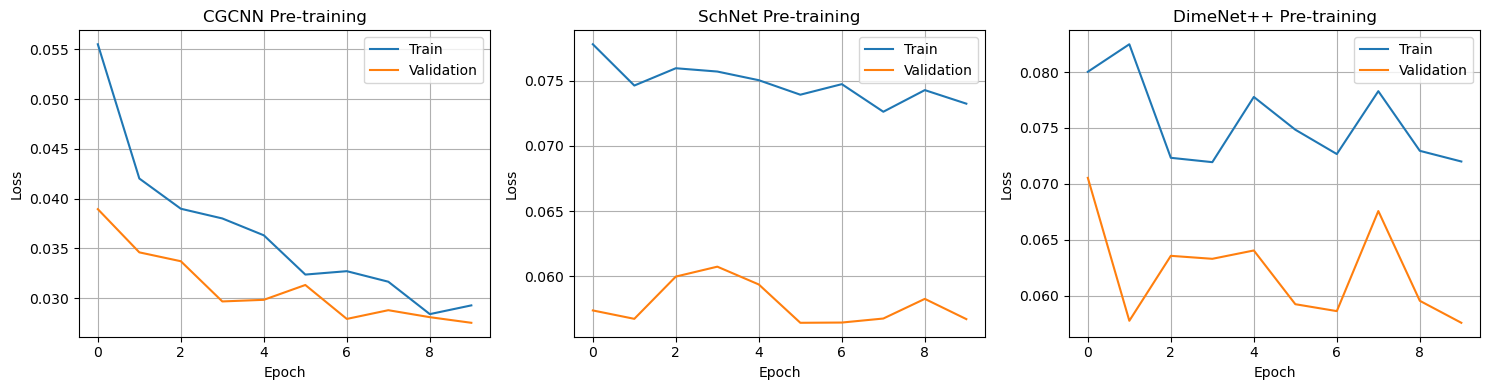

In [ ]:
# %% [markdown]
# ## 8. Предобучение GNN на MP18

# %%
def train_gnn(model, train_loader, val_loader, model_name, epochs=50, lr=0.001):
    """Обучение GNN"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f'{model_name} Epoch {epoch+1}/{epochs}'):
            optimizer.zero_grad()

            if model_name == "CGCNN":
                atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx, targets = batch
                atom_fea = atom_fea.to(device)
                nbr_fea = nbr_fea.to(device)
                nbr_fea_idx = nbr_fea_idx.to(device)
                targets = targets.to(device)
                output = model(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)

            elif model_name == "SchNet":
                atom_types, positions, targets = batch
                atom_types = atom_types.to(device)
                positions = positions.to(device)
                targets = targets.to(device)
                output = model(atom_types, positions)

            elif model_name == "DimeNet":
                atom_types_list, positions_list, targets = batch
                # DimeNet требует batch_size=1
                output = model(atom_types_list[0].to(device), positions_list[0].to(device))
                targets = targets.to(device)

            loss = criterion(output.squeeze(), targets.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                if model_name == "CGCNN":
                    atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx, targets = batch
                    atom_fea = atom_fea.to(device)
                    nbr_fea = nbr_fea.to(device)
                    nbr_fea_idx = nbr_fea_idx.to(device)
                    targets = targets.to(device)
                    output = model(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)

                elif model_name == "SchNet":
                    atom_types, positions, targets = batch
                    atom_types = atom_types.to(device)
                    positions = positions.to(device)
                    targets = targets.to(device)
                    output = model(atom_types, positions)

                elif model_name == "DimeNet":
                    atom_types_list, positions_list, targets = batch
                    # DimeNet требует batch_size=1
                    output = model(atom_types_list[0].to(device), positions_list[0].to(device))
                    targets = targets.to(device)

                loss = criterion(output.squeeze(), targets.squeeze())
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  {model_name} - Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses


# Инициализация и обучение моделей
print("="*50)
print("Начало предобучения CGCNN...")
print("="*50)
cgcnn_model = ImprovedCGCNN(atom_fea_len=64, n_conv=3, h_fea_len=128).to(device)
cgcnn_train_losses, cgcnn_val_losses = train_gnn(
    cgcnn_model, cgcnn_pretrain_loader, cgcnn_val_loader, "CGCNN", epochs=10
)
torch.save(cgcnn_model.state_dict(), 'pretrained_cgcnn.pth')
print("CGCNN предобучена и сохранена.")

print("\n" + "="*50)
print("Начало предобучения SchNet...")
print("="*50)
schnet_model = ImprovedSchNet(n_atom_basis=64, n_filters=64, n_interactions=3).to(device)
schnet_train_losses, schnet_val_losses = train_gnn(
    schnet_model, schnet_pretrain_loader, schnet_val_loader, "SchNet", epochs=10
)
torch.save(schnet_model.state_dict(), 'pretrained_schnet.pth')
print("SchNet предобучена и сохранена.")

print("\n" + "="*50)
print("Начало предобучения DimeNet++...")
print("="*50)
dimenet_model = CompleteDimeNetPlusPlus(
    num_atoms=93, emb_size=128, num_blocks=4, num_radial=32
).to(device)
dimenet_train_losses, dimenet_val_losses = train_gnn(
    dimenet_model, dimenet_pretrain_loader, dimenet_val_loader, "DimeNet", epochs=10
)
torch.save(dimenet_model.state_dict(), 'pretrained_dimenet.pth')
print("DimeNet++ предобучена и сохранена.")

# Визуализация графиков обучения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(cgcnn_train_losses, label='Train')
axes[0].plot(cgcnn_val_losses, label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('CGCNN Pre-training')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(schnet_train_losses, label='Train')
axes[1].plot(schnet_val_losses, label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('SchNet Pre-training')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(dimenet_train_losses, label='Train')
axes[2].plot(dimenet_val_losses, label='Validation')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('DimeNet++ Pre-training')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# %% [markdown]
# ## 9. Дообучение моделей на fine-tune данных

# %%
print("\n" + "="*60)
print("ДООБУЧЕНИЕ МОДЕЛЕЙ НА FINE-TUNE ДАННЫХ")
print("="*60)

# Разделение fine_tune на train и validation
fine_tune_train, fine_tune_val = train_test_split(
    fine_tune, test_size=0.2, random_state=42, shuffle=True
)

print(f"Fine-tune train: {len(fine_tune_train)}")
print(f"Fine-tune validation: {len(fine_tune_val)}")

# Создаем датасеты для fine-tune
cgcnn_ft_train_dataset = CGCNNDataset(fine_tune_train, radius=8.0)
cgcnn_ft_val_dataset = CGCNNDataset(fine_tune_val, radius=8.0)

schnet_ft_train_dataset = SchNetDataset(fine_tune_train)
schnet_ft_val_dataset = SchNetDataset(fine_tune_val)

dimenet_ft_train_dataset = DimeNetDataset(fine_tune_train, cutoff=5.0)
dimenet_ft_val_dataset = DimeNetDataset(fine_tune_val, cutoff=5.0)

# Загрузчики
batch_size_ft = 16

cgcnn_ft_train_loader = DataLoader(cgcnn_ft_train_dataset, batch_size=batch_size_ft,
                                    shuffle=True, collate_fn=collate_cgcnn_batch)
cgcnn_ft_val_loader = DataLoader(cgcnn_ft_val_dataset, batch_size=batch_size_ft,
                                  shuffle=False, collate_fn=collate_cgcnn_batch)

schnet_ft_train_loader = DataLoader(schnet_ft_train_dataset, batch_size=batch_size_ft,
                                     shuffle=True, collate_fn=collate_schnet_batch)
schnet_ft_val_loader = DataLoader(schnet_ft_val_dataset, batch_size=batch_size_ft,
                                   shuffle=False, collate_fn=collate_schnet_batch)

dimenet_ft_train_loader = DataLoader(dimenet_ft_train_dataset, batch_size=1,
                                      shuffle=True, collate_fn=collate_dimenet_batch)
dimenet_ft_val_loader = DataLoader(dimenet_ft_val_dataset, batch_size=1,
                                    shuffle=False, collate_fn=collate_dimenet_batch)


def finetune_model(model, train_loader, val_loader, model_name, epochs=30, lr=0.0001):
    """Дообучение модели с заморозкой первых слоев"""
    # Замораживаем все слои, кроме последних
    for param in model.parameters():
        param.requires_grad = False

    # Размораживаем последние слои
    if model_name == "CGCNN":
        for param in model.fc1.parameters():
            param.requires_grad = True
        for param in model.fc2.parameters():
            param.requires_grad = True
        for param in model.fc_out.parameters():
            param.requires_grad = True
    elif model_name == "SchNet":
        for param in model.fc1.parameters():
            param.requires_grad = True
        for param in model.fc2.parameters():
            param.requires_grad = True
        for param in model.fc_out.parameters():
            param.requires_grad = True
    elif model_name == "DimeNet":
        for param in model.out_mlp.parameters():
            param.requires_grad = True

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in tqdm(train_loader, desc=f'{model_name} Epoch {epoch+1}/{epochs}'):
            optimizer.zero_grad()

            if model_name == "CGCNN":
                atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx, targets = batch
                atom_fea = atom_fea.to(device)
                nbr_fea = nbr_fea.to(device)
                nbr_fea_idx = nbr_fea_idx.to(device)
                targets = targets.to(device)
                output = model(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)

            elif model_name == "SchNet":
                atom_types, positions, targets = batch
                atom_types = atom_types.to(device)
                positions = positions.to(device)
                targets = targets.to(device)
                output = model(atom_types, positions)

            elif model_name == "DimeNet":
                atom_types_list, positions_list, targets = batch
                output = model(atom_types_list[0].to(device), positions_list[0].to(device))
                targets = targets.to(device)

            loss = criterion(output.squeeze(), targets.squeeze())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                if model_name == "CGCNN":
                    atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx, targets = batch
                    atom_fea = atom_fea.to(device)
                    nbr_fea = nbr_fea.to(device)
                    nbr_fea_idx = nbr_fea_idx.to(device)
                    targets = targets.to(device)
                    output = model(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)

                elif model_name == "SchNet":
                    atom_types, positions, targets = batch
                    atom_types = atom_types.to(device)
                    positions = positions.to(device)
                    targets = targets.to(device)
                    output = model(atom_types, positions)

                elif model_name == "DimeNet":
                    atom_types_list, positions_list, targets = batch
                    output = model(atom_types_list[0].to(device), positions_list[0].to(device))
                    targets = targets.to(device)

                loss = criterion(output.squeeze(), targets.squeeze())
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

        if (epoch + 1) % 5 == 0:
            print(f"  {model_name} - Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    print(f"✅ {model_name} дообучен. Best Val Loss: {best_val_loss:.4f}")
    return model


# Дообучение
cgcnn_model = finetune_model(cgcnn_model, cgcnn_ft_train_loader, cgcnn_ft_val_loader, "CGCNN", epochs=10)
schnet_model = finetune_model(schnet_model, schnet_ft_train_loader, schnet_ft_val_loader, "SchNet", epochs=10)
dimenet_model = finetune_model(dimenet_model, dimenet_ft_train_loader, dimenet_ft_val_loader, "DimeNet", epochs=10)

print("\n✅ Все модели дообучены!")


ДООБУЧЕНИЕ МОДЕЛЕЙ НА FINE-TUNE ДАННЫХ
Fine-tune train: 404
Fine-tune validation: 102
Загрузка CGCNNDataset из 404 структур...
CGCNNDataset: успешно загружено 404 из 404 структур
Загрузка CGCNNDataset из 102 структур...
CGCNNDataset: успешно загружено 102 из 102 структур
Загрузка SchNetDataset из 404 структур...
SchNetDataset: успешно загружено 404 из 404 структур
Загрузка SchNetDataset из 102 структур...
SchNetDataset: успешно загружено 102 из 102 структур
Загрузка DimeNetDataset из 404 структур...
DimeNetDataset: успешно загружено 404 из 404 структур
Загрузка DimeNetDataset из 102 структур...
DimeNetDataset: успешно загружено 102 из 102 структур


CGCNN Epoch 1/10:   0%|          | 0/26 [00:00<?, ?it/s]

CGCNN Epoch 2/10:   0%|          | 0/26 [00:00<?, ?it/s]

CGCNN Epoch 3/10:   0%|          | 0/26 [00:00<?, ?it/s]

CGCNN Epoch 4/10:   0%|          | 0/26 [00:00<?, ?it/s]

...

DimeNet Epoch 7/10:   0%|          | 0/404 [00:00<?, ?it/s]

DimeNet Epoch 8/10:   0%|          | 0/404 [00:00<?, ?it/s]

DimeNet Epoch 9/10:   0%|          | 0/404 [00:00<?, ?it/s]

DimeNet Epoch 10/10:   0%|          | 0/404 [00:00<?, ?it/s]

  DimeNet - Epoch 10: Train Loss: 0.0732, Val Loss: 0.0890
✅ DimeNet дообучен. Best Val Loss: 0.0890

✅ Все модели дообучены!


In [ ]:
# %% [markdown]
# ## 10. Извлечение признаков и обучение SVR

# %%
def extract_features_single(model, dataset, model_name, device):
    """Извлекает признаки по одному образцу с возвратом индексов"""
    model.eval()
    features_dict = {}  # index -> features
    targets_dict = {}   # index -> target
    failed_indices = []

    print(f"\nИзвлечение признаков для {model_name}...")

    if model_name == "CGCNN":
        loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_cgcnn_batch)
    elif model_name == "SchNet":
        loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_schnet_batch)
    elif model_name == "DimeNet":
        loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=collate_dimenet_batch)
    else:
        return {}, {}, []

    with torch.no_grad():
        for idx, batch in enumerate(tqdm(loader, desc=f"{model_name}")):
            try:
                if model_name == "CGCNN":
                    atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx, batch_targets = batch
                    atom_fea = atom_fea.to(device)
                    nbr_fea = nbr_fea.to(device)
                    nbr_fea_idx = nbr_fea_idx.to(device)
                    feats = model.extract_features(atom_fea, nbr_fea, nbr_fea_idx, crystal_atom_idx)
                    target = batch_targets.cpu().numpy().flatten()[0]

                elif model_name == "SchNet":
                    atom_types, positions, batch_targets = batch
                    atom_types = atom_types.to(device)
                    positions = positions.to(device)
                    feats = model.extract_features(atom_types, positions)
                    target = batch_targets.cpu().numpy().flatten()[0]

                elif model_name == "DimeNet":
                    atom_types_list, positions_list, batch_targets = batch
                    feats = model.extract_features(atom_types_list[0].to(device), positions_list[0].to(device))
                    target = batch_targets.cpu().numpy().flatten()[0]

                features_dict[idx] = feats.cpu().numpy().flatten()
                targets_dict[idx] = target

            except Exception as e:
                print(f"  Ошибка на образце {idx}: {e}")
                failed_indices.append(idx)
                continue

    print(f"  {model_name}: успешно извлечено {len(features_dict)} признаков из {len(dataset)}")
    return features_dict, targets_dict, failed_indices


# ============================================
# Извлечение признаков для fine_tune
# ============================================
print("\n" + "="*60)
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ FINE_TUNE")
print("="*60)

cgcnn_dict, cgcnn_targets_dict, cgcnn_failed = extract_features_single(
    cgcnn_model, cgcnn_finetune_dataset, "CGCNN", device
)

schnet_dict, schnet_targets_dict, schnet_failed = extract_features_single(
    schnet_model, schnet_finetune_dataset, "SchNet", device
)

dimenet_dict, dimenet_targets_dict, dimenet_failed = extract_features_single(
    dimenet_model, dimenet_finetune_dataset, "DimeNet", device
)

# ============================================
# Синхронизация признаков по общим индексам
# ============================================
print("\n" + "="*60)
print("СИНХРОНИЗАЦИЯ ПРИЗНАКОВ")
print("="*60)

# Находим общие успешные индексы
common_indices = set(cgcnn_dict.keys()) & set(schnet_dict.keys()) & set(dimenet_dict.keys())
common_indices = sorted(list(common_indices))

print(f"CGCNN успешных: {len(cgcnn_dict)}")
print(f"SchNet успешных: {len(schnet_dict)}")
print(f"DimeNet успешных: {len(dimenet_dict)}")
print(f"Общих успешных образцов: {len(common_indices)}")

if len(common_indices) == 0:
    raise ValueError("Нет общих образцов между моделями! Проверьте датасеты.")

# Собираем признаки
X_train_list = []
y_train_list = []

for idx in common_indices:
    combined = np.hstack([cgcnn_dict[idx], schnet_dict[idx], dimenet_dict[idx]])
    X_train_list.append(combined)
    y_train_list.append(cgcnn_targets_dict[idx])

X_train = np.vstack(X_train_list)
y_train = np.array(y_train_list)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


# ============================================
# Извлечение признаков для test
# ============================================
print("\n" + "="*60)
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ TEST")
print("="*60)

cgcnn_test_dict, cgcnn_test_targets_dict, cgcnn_test_failed = extract_features_single(
    cgcnn_model, cgcnn_test_dataset, "CGCNN", device
)

schnet_test_dict, schnet_test_targets_dict, schnet_test_failed = extract_features_single(
    schnet_model, schnet_test_dataset, "SchNet", device
)

dimenet_test_dict, dimenet_test_targets_dict, dimenet_test_failed = extract_features_single(
    dimenet_model, dimenet_test_dataset, "DimeNet", device
)

# Синхронизация тестовых признаков
common_test_indices = set(cgcnn_test_dict.keys()) & set(schnet_test_dict.keys()) & set(dimenet_test_dict.keys())
common_test_indices = sorted(list(common_test_indices))

print(f"\nОбщих тестовых образцов: {len(common_test_indices)}")

if len(common_test_indices) == 0:
    raise ValueError("Нет общих тестовых образцов между моделями!")

X_test_list = []
y_test_list = []

for idx in common_test_indices:
    combined = np.hstack([cgcnn_test_dict[idx], schnet_test_dict[idx], dimenet_test_dict[idx]])
    X_test_list.append(combined)
    y_test_list.append(cgcnn_test_targets_dict[idx])

X_test = np.vstack(X_test_list)
y_test = np.array(y_test_list)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Проверка на NaN
print("\n" + "="*60)
print("ПРОВЕРКА НА NaN")
print("="*60)

nan_train = np.isnan(X_train).sum()
nan_test = np.isnan(X_test).sum()
print(f"X_train NaN: {nan_train}")
print(f"X_test NaN: {nan_test}")

if nan_train > 0 or nan_test > 0:
    print("Замена NaN на 0...")
    X_train = np.nan_to_num(X_train, nan=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0)


# ============================================
# Обучение SVR
# ============================================
print("\n" + "="*60)
print("ОБУЧЕНИЕ SVR")
print("="*60)

# Аугментация данных (опционально)
def augment_regression_data(X, y, noise_std=0.005, n_copies=1):
    """Аугментация данных с шумом"""
    X_aug = X.copy()
    y_aug = y.copy()
    for _ in range(n_copies):
        noise_X = np.random.normal(0, noise_std, X.shape)
        noise_y = np.random.normal(0, noise_std * np.std(y), y.shape)
        X_aug = np.vstack([X_aug, X + noise_X])
        y_aug = np.hstack([y_aug, y + noise_y])
    return X_aug, y_aug

X_train_aug, y_train_aug = augment_regression_data(X_train, y_train, noise_std=0.005, n_copies=1)
print(f"После аугментации: {X_train_aug.shape[0]} образцов")

# Пайплайн
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.05))
])

param_grid = {
    'svr__C': [1, 5, 10, 20, 50],
    'svr__gamma': ['scale', 0.1, 0.05, 0.01],
    'svr__epsilon': [0.01, 0.02, 0.05, 0.1]
}

print("\nПоиск гиперпараметров (5-fold CV)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=kf,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1, verbose=1)
grid_search.fit(X_train_aug, y_train_aug)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f} eV/atom")

best_model = grid_search.best_estimator_

print("\n✅ Модель обучена")


ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ FINE_TUNE

Извлечение признаков для CGCNN...


CGCNN:   0%|          | 0/506 [00:00<?, ?it/s]

  Ошибка на образце 28: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 70: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 162: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 204: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 233: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 294: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 297: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 371: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 379: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 422: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 493: Dimension out of 

SchNet:   0%|          | 0/506 [00:00<?, ?it/s]

  SchNet: успешно извлечено 506 признаков из 506

Извлечение признаков для DimeNet...


...

  Ошибка на образце 732: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 734: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 738: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 743: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 749: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 751: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 757: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 759: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 761: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 763: Dimension out of range (expected to be in range of [-1, 0], but got 1)
  Ошибка на образце 766: Dimension out o

SchNet:   0%|          | 0/5539 [00:00<?, ?it/s]

  SchNet: успешно извлечено 5539 признаков из 5539

Извлечение признаков для DimeNet...


DimeNet:   0%|          | 0/5539 [00:00<?, ?it/s]

  DimeNet: успешно извлечено 5539 признаков из 5539

Общих тестовых образцов: 5486
X_test shape: (5486, 320)
y_test shape: (5486,)

ПРОВЕРКА НА NaN
X_train NaN: 0
X_test NaN: 0

ОБУЧЕНИЕ SVR
После аугментации: 990 образцов

Поиск гиперпараметров (5-fold CV)...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

Best parameters: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 0.01}
Best CV RMSE: 0.1046 eV/atom

✅ Модель обучена



ОЦЕНКА МОДЕЛИ

--- ТРЕНИРОВОЧНЫЕ ДАННЫЕ (fine_tune) ---
  RMSE: 0.0149 eV/atom
  MAE: 0.0109 eV/atom
  R²: 0.9971

--- ТЕСТОВЫЕ ДАННЫЕ (MP21 new) ---
  RMSE: 0.9458 eV/atom
  MAE: 0.4719 eV/atom
  R²: -0.2860

Baseline (mean) RMSE: 0.9633 eV/atom

✅ Модель работает лучше базовой линии!

АНАЛИЗ ИНТЕРПОЛЯЦИИ/ЭКСТРАПОЛЯЦИИ
Диапазон fine_tune: [-0.905, 0.994] eV/atom
Диапазон test: [-0.953, 4.416] eV/atom

Интерполяция: 4757 образцов
Экстраполяция: 729 образцов

Интерполяция RMSE: 0.2600 eV/atom
Экстраполяция RMSE: 2.5081 eV/atom

ВИЗУАЛИЗАЦИЯ


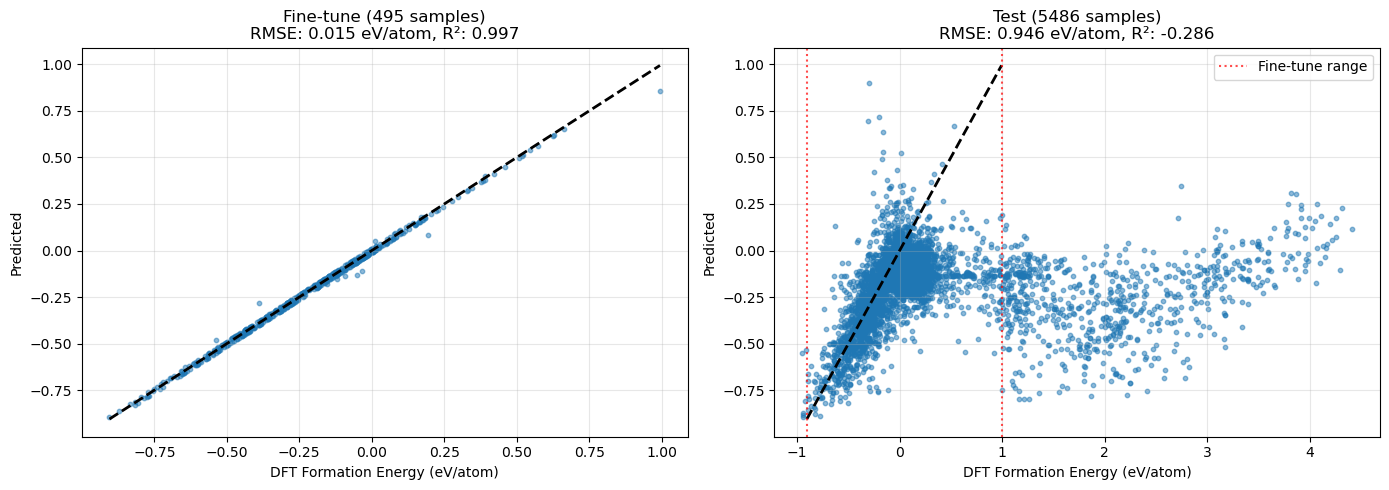


✅ Все готово!


In [ ]:
# %% [markdown]
# ## 11. Оценка модели и визуализация

# %%
print("\n" + "="*60)
print("ОЦЕНКА МОДЕЛИ")
print("="*60)

# Предсказания
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# Метрики
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\n--- ТРЕНИРОВОЧНЫЕ ДАННЫЕ (fine_tune) ---")
print(f"  RMSE: {train_rmse:.4f} eV/atom")
print(f"  MAE: {train_mae:.4f} eV/atom")
print(f"  R²: {train_r2:.4f}")

print(f"\n--- ТЕСТОВЫЕ ДАННЫЕ (MP21 new) ---")
print(f"  RMSE: {test_rmse:.4f} eV/atom")
print(f"  MAE: {test_mae:.4f} eV/atom")
print(f"  R²: {test_r2:.4f}")

# Базовая линия
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"\nBaseline (mean) RMSE: {baseline_rmse:.4f} eV/atom")

if test_rmse < baseline_rmse:
    print("\n✅ Модель работает лучше базовой линии!")
else:
    print("\n⚠️ Модель работает хуже базовой линии")

# Анализ интерполяции/экстраполяции
print("\n" + "="*60)
print("АНАЛИЗ ИНТЕРПОЛЯЦИИ/ЭКСТРАПОЛЯЦИИ")
print("="*60)

train_min = fine_tune['formation_energy_per_atom'].min()
train_max = fine_tune['formation_energy_per_atom'].max()

print(f"Диапазон fine_tune: [{train_min:.3f}, {train_max:.3f}] eV/atom")
print(f"Диапазон test: [{y_test.min():.3f}, {y_test.max():.3f}] eV/atom")

interp_mask = (y_test >= train_min) & (y_test <= train_max)
extrap_mask = ~interp_mask

print(f"\nИнтерполяция: {interp_mask.sum()} образцов")
print(f"Экстраполяция: {extrap_mask.sum()} образцов")

if interp_mask.sum() > 0:
    y_test_interp = y_test[interp_mask]
    y_pred_interp = y_pred_test[interp_mask]
    rmse_interp = np.sqrt(mean_squared_error(y_test_interp, y_pred_interp))
    print(f"\nИнтерполяция RMSE: {rmse_interp:.4f} eV/atom")

if extrap_mask.sum() > 0:
    y_test_extrap = y_test[extrap_mask]
    y_pred_extrap = y_pred_test[extrap_mask]
    rmse_extrap = np.sqrt(mean_squared_error(y_test_extrap, y_pred_extrap))
    print(f"Экстраполяция RMSE: {rmse_extrap:.4f} eV/atom")

# Визуализация
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training predictions
axes[0].scatter(y_train, y_pred_train, alpha=0.5, s=10)
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
axes[0].set_xlabel('DFT Formation Energy (eV/atom)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Fine-tune ({len(y_train)} samples)\nRMSE: {train_rmse:.3f} eV/atom, R²: {train_r2:.3f}')
axes[0].grid(True, alpha=0.3)

# Test predictions
axes[1].scatter(y_test, y_pred_test, alpha=0.5, s=10)
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
axes[1].axvline(x=train_max, color='red', linestyle=':', alpha=0.7, label=f'Fine-tune range')
axes[1].axvline(x=train_min, color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel('DFT Formation Energy (eV/atom)')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Test ({len(y_test)} samples)\nRMSE: {test_rmse:.3f} eV/atom, R²: {test_r2:.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Все готово!")